# Vibepixel Avatar Pipeline

Este notebook sigue el flujo de Colab para importar la planilla, previsualizar el avatar y exportar. La primera celda intenta usar `avatar_pipeline.py` local y, si falta, lo descarga automáticamente desde el repositorio público con un tiempo de espera corto. La celda del CSV también baja un ejemplo (un avatar de husky) en la primera corrida si no encuentra `avatar-16x16.csv`, así podés ver un resultado sin pasos extra. Mantené los valores RGB entre comillas como un solo campo CSV, por ejemplo `"255,204,0"`.


In [29]:
from pathlib import Path
import importlib.util
import sys
import urllib.request

AVATAR_PIPELINE_URL = "https://raw.githubusercontent.com/HaroldSthid/VibePixel-AcademyBabyStepsTech/main/artifacts/colab/avatar_pipeline.py"
SAMPLE_CSV_URL = "https://raw.githubusercontent.com/HaroldSthid/VibePixel-AcademyBabyStepsTech/main/artifacts/spreadsheet/templates/avatar-16x16.csv"
MODULE_PATH = Path("avatar_pipeline.py")
DOWNLOAD_TIMEOUT_SECONDS = 10
DOWNLOAD_ATTEMPTS = 2

def _download_file(url, destination, *, label):
    last_exc = None
    for attempt in range(1, DOWNLOAD_ATTEMPTS + 1):
        try:
            with urllib.request.urlopen(url, timeout=DOWNLOAD_TIMEOUT_SECONDS) as response:
                destination.write_bytes(response.read())
            return
        except Exception as download_exc:
            last_exc = download_exc
            if attempt < DOWNLOAD_ATTEMPTS:
                print(f"No se pudo descargar {label} en el intento {attempt}. Reintentamos una vez más.")
    raise RuntimeError(
        f"No pudimos descargar {label} automáticamente en {DOWNLOAD_TIMEOUT_SECONDS} segundos por intento. "
        "Revisá tu conexión a internet y volvé a ejecutar la celda."
    ) from last_exc

def _load_avatar_pipeline():
    try:
        from avatar_pipeline import export_avatar, load_avatar_frames, preview_avatar
        return export_avatar, load_avatar_frames, preview_avatar
    except ImportError:
        if not MODULE_PATH.exists():
            try:
                _download_file(AVATAR_PIPELINE_URL, MODULE_PATH, label="avatar_pipeline.py")
            except RuntimeError as download_exc:
                raise ImportError(
                    "No pudimos cargar avatar_pipeline.py automáticamente. Verificá tu conexión a internet y volvé a ejecutar la celda."
                ) from download_exc

        try:
            spec = importlib.util.spec_from_file_location("avatar_pipeline", MODULE_PATH)
            if spec is None or spec.loader is None:
                raise ImportError("No se pudo preparar la carga de avatar_pipeline.py.")
            module = importlib.util.module_from_spec(spec)
            sys.modules["avatar_pipeline"] = module
            spec.loader.exec_module(module)
            return module.export_avatar, module.load_avatar_frames, module.preview_avatar
        except Exception as load_exc:
            raise ImportError(
                "No pudimos cargar avatar_pipeline.py automáticamente. Verificá que el notebook tenga acceso a internet y volvé a ejecutar la celda."
            ) from load_exc

export_avatar, load_avatar_frames, preview_avatar = _load_avatar_pipeline()


In [30]:
source_csv = Path("/content/VALMON-cabe.csv")

if not source_csv.exists():
    raise FileNotFoundError("Sube VALMON-cabe.csv a Colab antes de continuar.")


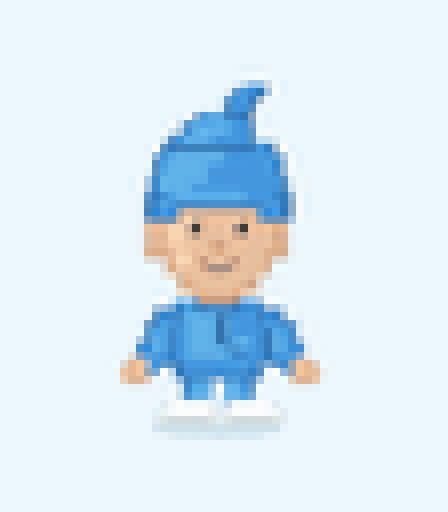

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
import pandas as pd
import numpy as np
from PIL import Image
from IPython.display import display, Image as MostrarImagen
from google.colab import files
import math

# Leer la imagen completa
df = pd.read_csv("/content/VALMON-cabe.csv")
df = df[df["frame_id"] == df["frame_id"].iloc[0]]

alto = int(df["row"].max()) + 1
ancho = int(df["col"].max()) + 1
imagen = np.full((alto, ancho, 3), 255, dtype=np.uint8)

for _, pixel in df.iterrows():
    color = str(pixel["value"]).strip().lstrip("#")
    rgb = tuple(int(color[i:i+2], 16) for i in (0, 2, 4))
    imagen[int(pixel["row"]), int(pixel["col"])] = rgb

base = Image.fromarray(imagen)

# Una misma paleta para evitar cambios de color entre frames
paleta = base.quantize(colors=255)
fondo = tuple(int(v) for v in imagen[0, 0])

# Añadir espacio para moverse sin recortar la imagen
margen = 8
tamano = (ancho + margen * 2, alto + margen * 2)
frames = []

for i in range(24):
    fase = 2 * math.pi * i / 24
    x = margen + round(3 * math.sin(fase))
    y = margen - round(6 * (1 - math.cos(fase)) / 2)

    frame = Image.new("RGB", tamano, fondo)
    frame.paste(base, (x, y))
    frame = frame.quantize(
        palette=paleta,
        dither=Image.Dither.NONE
    )
    frame = frame.resize(
        (tamano[0] * 8, tamano[1] * 8),
        Image.Resampling.NEAREST
    )
    frames.append(frame)

# Guardar la animación en bucle
ruta = "/content/VALMON_animado.gif"
frames[0].save(
    ruta,
    save_all=True,
    append_images=frames[1:],
    duration=80,
    loop=0,
    disposal=2,
    optimize=False
)

display(MostrarImagen(filename=ruta))
files.download(ruta)


In [32]:
result = export_avatar(frames, output_dir=Path("exports"), stem="avatar")
result


{'kind': 'still',
 'frame_count': 1,
 'frame_id': 'VALMON_01',
 'path': 'exports/avatar_preview.png',
 'message': 'Only one frame was found, so the export is a still preview image.'}

## Fallback para una sola imagen

Si la exportación contiene un solo frame, el pipeline escribe `avatar_preview.png` en lugar de un GIF animado. Usá esa imagen fija para el siguiente paso del taller. Ejecutá `validate_avatar_pipeline.py` para verificar el contrato de importación, previsualización y exportación antes de compartir el artefacto. La celda de importación ya maneja automáticamente el fallback de descarga.
